In [104]:
import pandas as pd

In [105]:
df = pd.read_csv('supermarket_sales - Sheet1.csv')
print(df.head(10))
print(df.info())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   
5  699-14-3026      C  Naypyitaw        Normal    Male   
6  355-53-5943      A     Yangon        Member  Female   
7  315-22-5665      C  Naypyitaw        Normal  Female   
8  665-32-9167      A     Yangon        Member  Female   
9  692-92-5582      B   Mandalay        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22

In [106]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [107]:
df1 = df.groupby('Date')['Total'].sum().reset_index()
df1 = df1.sort_values('Date')
print(df1)

         Date      Total
0  2019-01-01  4745.1810
1  2019-01-02  1945.5030
2  2019-01-03  2078.1285
3  2019-01-04  1623.6885
4  2019-01-05  3536.6835
..        ...        ...
84 2019-03-26  1962.5130
85 2019-03-27  2902.8195
86 2019-03-28  2229.4020
87 2019-03-29  4023.2430
88 2019-03-30  4487.0595

[89 rows x 2 columns]


In [109]:
import matplotlib.pyplot as plt

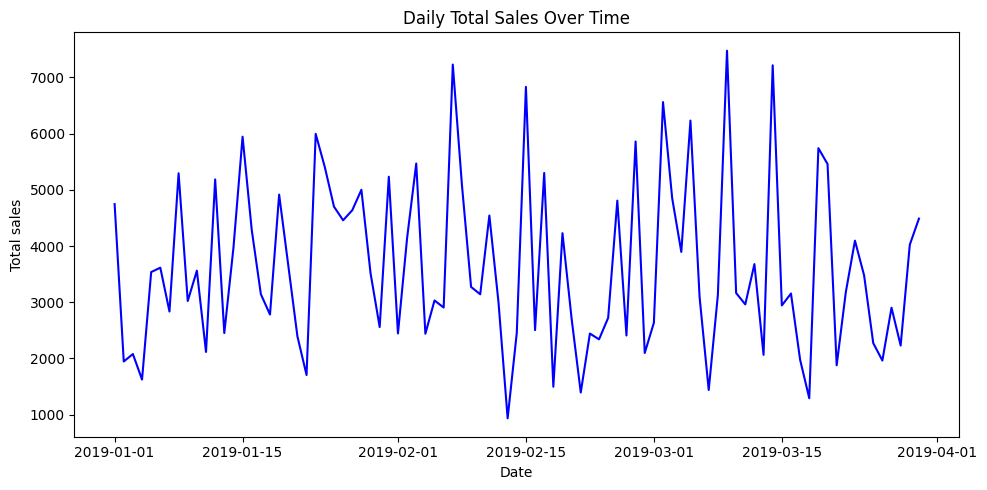

In [110]:
plt.figure(figsize=(10,5))
plt.plot(df1['Date'],df1['Total'],color= 'blue')
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total sales')
plt.tight_layout()
plt.show()

In [111]:
split = int(len(df1) * 2/3)
train = df1[:split]
print(train.head())
test = df1[split:]
print(test.head())
print(f"Length - Training Datasets: {len(train)}")
print(f"Length - Testing Datasets: {len(test)}")

        Date      Total
0 2019-01-01  4745.1810
1 2019-01-02  1945.5030
2 2019-01-03  2078.1285
3 2019-01-04  1623.6885
4 2019-01-05  3536.6835
         Date      Total
59 2019-03-01  2634.3660
60 2019-03-02  6560.3055
61 2019-03-03  4853.1735
62 2019-03-04  3894.4395
63 2019-03-05  6230.8785
Length - Training Datasets: 59
Length - Testing Datasets: 30


In [112]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , mean_absolute_percentage_error

In [113]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
from statsmodels.tsa.arima.model import ARIMA
from math import sqrt

In [119]:
model = ARIMA(df1['Total'],order=(0,1,1))
model_fit = model.fit()

In [120]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Total   No. Observations:                   89
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -771.993
Date:                Mon, 27 Apr 2026   AIC                           1547.985
Time:                        09:31:17   BIC                           1552.940
Sample:                             0   HQIC                          1549.981
                                 - 89                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9999      0.168     -5.962      0.000      -1.329      -0.671
sigma2       2.33e+06   7.22e-08   3.23e+13      0.000    2.33e+06    2.33e+06
Ljung-Box (L1) (Q):                   0.13   Jarque-

In [121]:
predictions = model_fit.forecast(steps=len(test))
predictions.index = test['Date']
print(predictions)
mse = mean_squared_error(test['Total'],predictions)
print(f"MSE: {mse}")
mae = mean_absolute_error(test['Total'],predictions)
print(f"MAE: {mae}")
mape = mean_absolute_percentage_error(test['Total'],predictions)
print(f"MAPE: {mape}")
rmse = sqrt(mse)
print(f"RMSE: {rmse}")

Date
2019-03-01    3600.532051
2019-03-02    3600.532051
2019-03-03    3600.532051
2019-03-04    3600.532051
2019-03-05    3600.532051
2019-03-06    3600.532051
2019-03-07    3600.532051
2019-03-08    3600.532051
2019-03-09    3600.532051
2019-03-10    3600.532051
2019-03-11    3600.532051
2019-03-12    3600.532051
2019-03-13    3600.532051
2019-03-14    3600.532051
2019-03-15    3600.532051
2019-03-16    3600.532051
2019-03-17    3600.532051
2019-03-18    3600.532051
2019-03-19    3600.532051
2019-03-20    3600.532051
2019-03-21    3600.532051
2019-03-22    3600.532051
2019-03-23    3600.532051
2019-03-24    3600.532051
2019-03-25    3600.532051
2019-03-26    3600.532051
2019-03-27    3600.532051
2019-03-28    3600.532051
2019-03-29    3600.532051
2019-03-30    3600.532051
Name: predicted_mean, dtype: float64
MSE: 2742321.0907640336
MAE: 1318.8542102113756
MAPE: 0.43335167385603846
RMSE: 1655.9954984129738


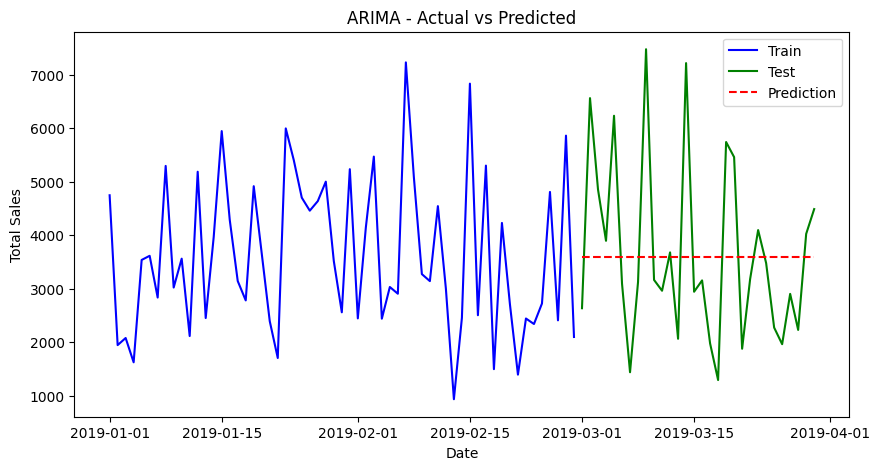

In [122]:
plt.figure(figsize=(10,5))
plt.plot(train['Date'],train['Total'],label='Train',color='blue')
plt.plot(test['Date'],test['Total'],label='Test',color='green')
plt.plot(predictions.index,predictions,label='Prediction',color='red',linestyle ='--')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('ARIMA - Actual vs Predicted')
plt.legend()
plt.show()
